In [1]:
import pandas as pd

# Date Formats and Date Parts

* First, convert the `date` column to datetime64, by any method.

* Then, create a column representing the time difference between the last date in the data and each date. 

* Next, create columns for the date parts year, month, and weekday.

* Finally, format the date to Year-Month-Day (This will be a string/object).

In [6]:
# read in transactions.csv 
transactions = pd.read_csv("transactions.csv", parse_dates=["date"])

In [7]:
transactions["time_to_last_date"] = transactions["date"].max() - transactions["date"]

In [9]:
transactions["date"] = transactions["date"].astype("datetime64[ns]")

In [11]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   date               83488 non-null  datetime64[ns] 
 1   store_nbr          83488 non-null  int64          
 2   transactions       83488 non-null  int64          
 3   time_to_last_date  83488 non-null  timedelta64[ns]
dtypes: datetime64[ns](1), int64(2), timedelta64[ns](1)
memory usage: 2.5 MB


In [13]:
transactions.head()

,date,store_nbr,transactions,time_to_last_date
0,2013-01-01,25,770,1687 days
1,2013-01-02,1,2111,1686 days
2,2013-01-02,2,2358,1686 days
3,2013-01-02,3,3487,1686 days
4,2013-01-02,4,1922,1686 days


In [14]:
transactions["date"].max()

Timestamp('2017-08-15 00:00:00')

In [15]:
transactions["time_to_last_date"] = transactions["date"].max() - transactions["date"]

transactions["year"] = transactions["date"].dt.year
transactions["month"] = transactions["date"].dt.month
transactions["day_of_week"] = transactions["date"].dt.weekday

transactions["date"] = transactions["date"].dt.strftime("%Y-%B-%d")

transactions.head()

,date,store_nbr,transactions,time_to_last_date,year,month,day_of_week
0,2013-January-01,25,770,1687 days,2013,1,1
1,2013-January-02,1,2111,1686 days,2013,1,2
2,2013-January-02,2,2358,1686 days,2013,1,2
3,2013-January-02,3,3487,1686 days,2013,1,2
4,2013-January-02,4,1922,1686 days,2013,1,2


# Time Arithmetic


Hi again,

I just got word the the true max date in our data was three weeks after 2017-08-15.

* Can you add three weeks to the ‘time_to_last_date’ column? 
* Then, calculate ‘weeks_to_last_date’ by dividing the number of days  in ‘time_to_last_date’ by 7.

Thanks

In [19]:

transactions = pd.read_csv("transactions.csv", parse_dates=["date"])

In [20]:
transactions.tail()

,date,store_nbr,transactions
83483,2017-08-15,50,2804
83484,2017-08-15,51,1573
83485,2017-08-15,52,2255
83486,2017-08-15,53,932
83487,2017-08-15,54,802


In [21]:

transactions = transactions.assign(
    year=transactions["date"].dt.year,
    month=transactions["date"].dt.month,
    day_of_week=transactions["date"].dt.dayofweek,
    time_to_last_date=transactions["date"].max() - transactions["date"],
)

transactions.head()

,date,store_nbr,transactions,year,month,day_of_week,time_to_last_date
0,2013-01-01,25,770,2013,1,1,1687 days
1,2013-01-02,1,2111,2013,1,2,1686 days
2,2013-01-02,2,2358,2013,1,2,1686 days
3,2013-01-02,3,3487,2013,1,2,1686 days
4,2013-01-02,4,1922,2013,1,2,1686 days


In [22]:
transactions.assign(
    time_to_last_date=pd.to_timedelta(21, unit="D") + transactions["time_to_last_date"],
    weeks_to_last_date=(lambda x: x["time_to_last_date"].dt.days / 7),
).head()

,date,store_nbr,transactions,year,month,day_of_week,time_to_last_date,weeks_to_last_date
0,2013-01-01,25,770,2013,1,1,1708 days,244.000000
1,2013-01-02,1,2111,2013,1,2,1707 days,243.857143
2,2013-01-02,2,2358,2013,1,2,1707 days,243.857143
3,2013-01-02,3,3487,2013,1,2,1707 days,243.857143
4,2013-01-02,4,1922,2013,1,2,1707 days,243.857143


# Missing Time Series Data

Take a look at the mean value for the oil price using forward fill, backfill, and interpolation. Are they very different?

Then, plot the series with forward fill for:
 * The year 2014.
 * The month of December 2014.
 * The days from December 1st to December 15th, 2014.


In [23]:
# Read in oil csv with date as index (and converted to datetime64)
oil = pd.read_csv("oil.csv", 
                  index_col="date", 
                  parse_dates=True)

In [24]:
# This is a synonym for datetime64

oil.index.dtype

dtype('<M8[ns]')

In [25]:
# mean of original series

oil.mean()

dcoilwtico    67.714366
dtype: float64

<Axes: xlabel='date'>

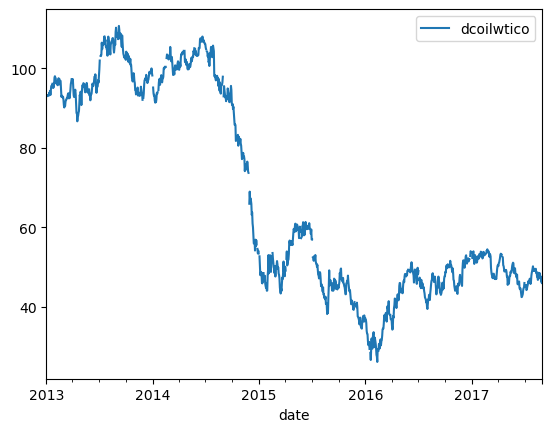

In [26]:
# original plot

oil.plot()

In [27]:
print (oil.ffill().mean(), oil.bfill().mean(), oil.interpolate().mean())

dcoilwtico    67.671249
dtype: float64 dcoilwtico    67.673325
dtype: float64 dcoilwtico    67.661824
dtype: float64


<Axes: xlabel='date'>

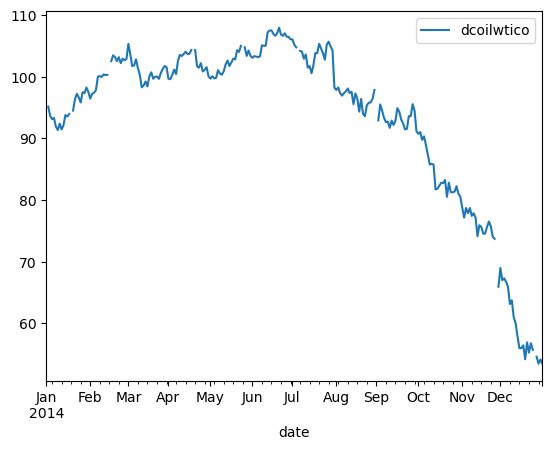

In [28]:
oil.loc["2014"].plot()

<Axes: xlabel='date'>

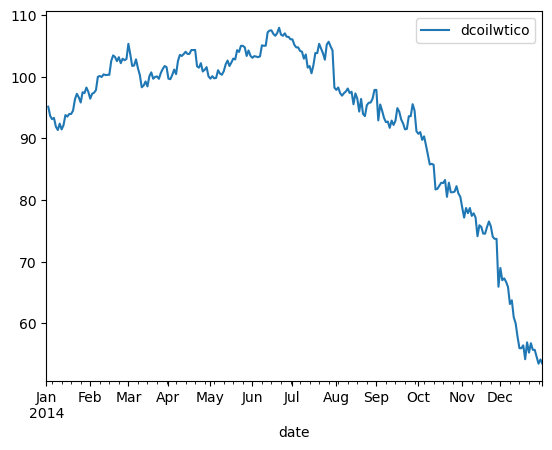

In [29]:
oil.loc["2014"].ffill().plot()

<Axes: xlabel='date'>

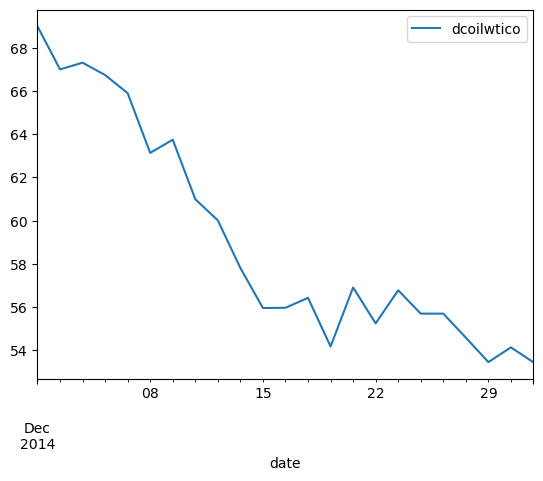

In [30]:
oil.loc["2014-12"].ffill().plot()

<Axes: xlabel='date'>

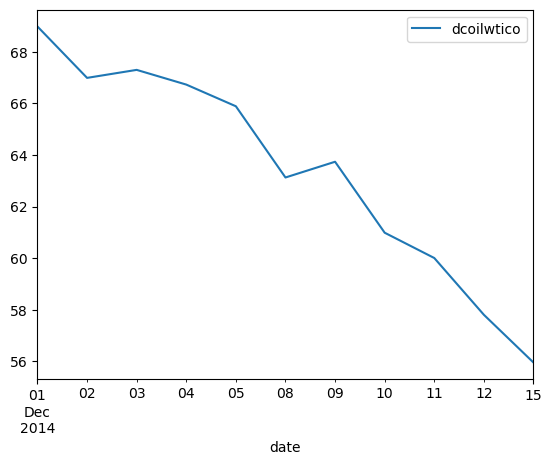

In [31]:
oil.loc["2014-12-01":"2014-12-15"].ffill().plot()

# Resampling Time Series

Plot the monthly and yearly average oil prices.

In [38]:
oil.head()

,dcoilwtico
date,
2013-01-01,NaN
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-07,93.20


<Axes: xlabel='date'>

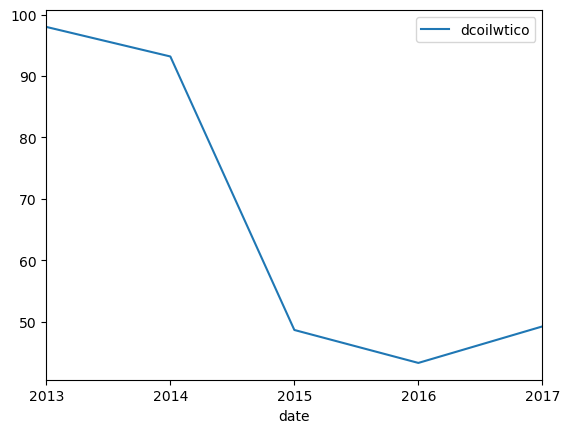

In [40]:
oil.resample("YE").mean().plot()

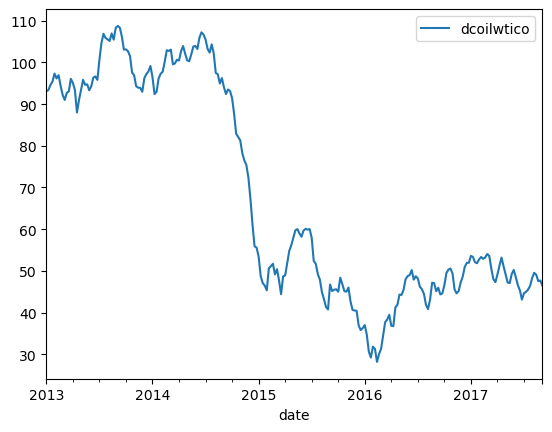

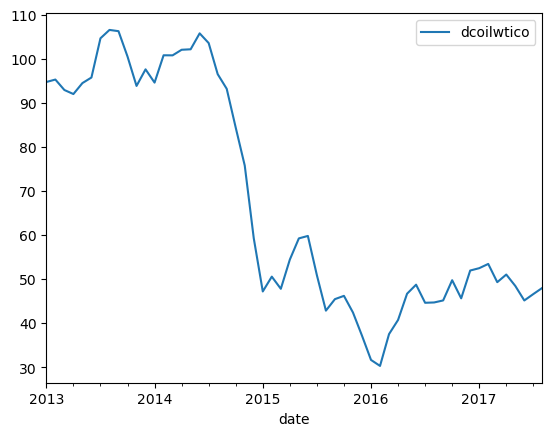

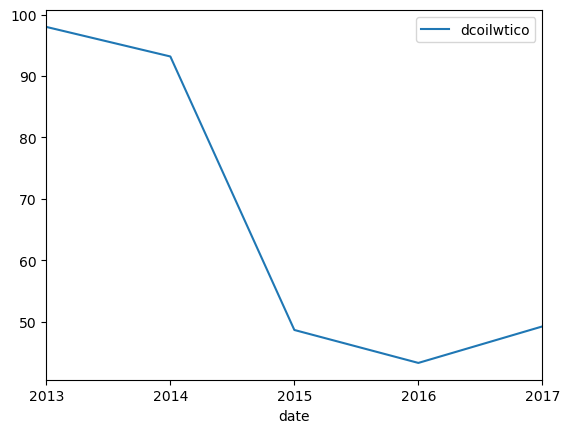

In [46]:
for period in ["W", "ME", "YE"]:
    oil.resample(period).mean().plot()

# Rolling Averages

Plot the 90-day moving average for transactions for store 47.

This will help remove some of the noise from our series.

Thanks!


In [47]:
# recreate transactions_47 with date as index 

transactions_47 = (transactions
                   .loc[transactions["store_nbr"]==47, ["date", "transactions"]]
                   .set_index("date"))

transactions_47.head()

,transactions
date,
2013-01-02,4161
2013-01-03,3660
2013-01-04,3915
2013-01-05,4764
2013-01-06,4935


<Axes: xlabel='date'>

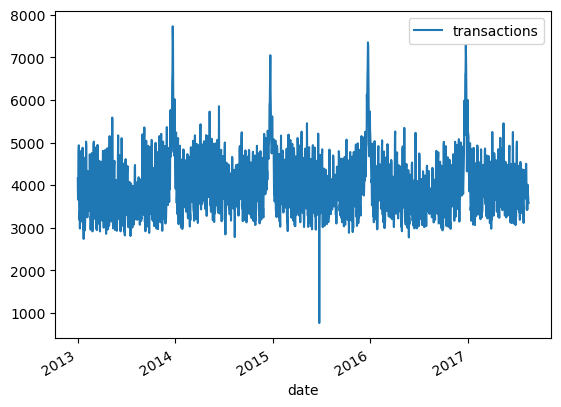

In [48]:
# original daily series for comparison

transactions_47.plot()

<Axes: xlabel='date'>

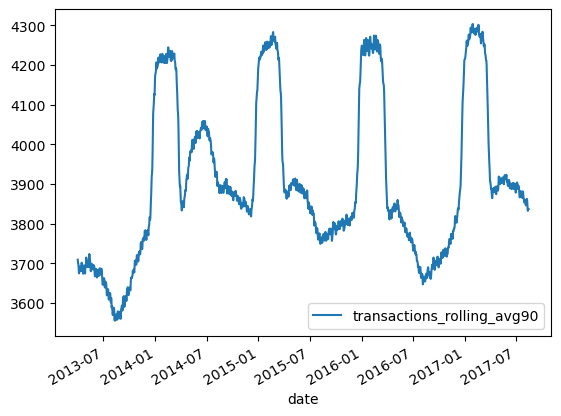

In [53]:
(transactions_47
 .assign(transactions_rolling_avg90 = transactions_47['transactions'].rolling(90).mean())
 .drop(['transactions'], axis=1)  
 .plot()
)